# Lab | Neural Networks Fundamentals

## Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

### Task 1 — A Single Neuron in NumPy

In [2]:
# 1. Load, split and scale
data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Single-neuron forward pass
w = np.random.randn(30) * 0.01
b = np.random.randn() * 0.01

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(x, w, b):
    return sigmoid(np.dot(x, w) + b)

probs = [forward(X_test_scaled[i], w, b) for i in range(5)]
print("Predicted probabilities for first 5 test rows:")
print(probs)

Predicted probabilities for first 5 test rows:
[np.float64(0.4962245695737439), np.float64(0.5175402839909198), np.float64(0.5070800493970136), np.float64(0.4874400158003255), np.float64(0.4839460770261141)]


**1.** This model is essentially a Logistic Regression model implemented as a single neuron with a sigmoid activation function.

### Task 2 — A Two-Layer MLP in NumPy

In [3]:
class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        # He initialization
        self.W1 = np.random.normal(0, np.sqrt(2/input_size), (input_size, hidden_size))
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.normal(0, np.sqrt(2/hidden_size), (hidden_size, output_size))
        self.b2 = np.zeros((1, output_size))
        
    def relu(self, Z):
        return np.maximum(0, Z)
    
    def forward(self, X):
        self.Z1 = np.dot(X, self.W1) + self.b1
        self.A1 = self.relu(self.Z1)
        self.Z2 = np.dot(self.A1, self.W2) + self.b2
        self.A2 = sigmoid(self.Z2)
        return self.A2

mlp_numpy = NumpyMLP()
numpy_output = mlp_numpy.forward(X_test_scaled)
print(f"Output shape: {numpy_output.shape}")
print("First 5 predictions:")
print(numpy_output[:5])

Output shape: (114, 1)
First 5 predictions:
[[0.52073256]
 [0.12562479]
 [0.54742783]
 [0.42673528]
 [0.44082567]]


**2.** The output shape matches a binary classifier because the final layer has a single unit with a sigmoid activation, producing one probability value per input sample regardless of training status.

### Task 3 — The Same Network in PyTorch

In [4]:
class TorchMLP(nn.Module):
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        super(TorchMLP, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.sigmoid = nn.Sigmoid()
        
    def forward(self, x):
        z1 = self.fc1(x)
        a1 = self.relu(z1)
        z2 = self.fc2(a1)
        a2 = self.sigmoid(z2)
        return a2, z1, a1

model_torch = TorchMLP()

# Copy weights
with torch.no_grad():
    model_torch.fc1.weight.copy_(torch.from_numpy(mlp_numpy.W1.T).float())
    model_torch.fc1.bias.copy_(torch.from_numpy(mlp_numpy.b1.flatten()).float())
    model_torch.fc2.weight.copy_(torch.from_numpy(mlp_numpy.W2.T).float())
    model_torch.fc2.bias.copy_(torch.from_numpy(mlp_numpy.b2.flatten()).float())

X_test_tensor = torch.from_numpy(X_test_scaled).float()
with torch.no_grad():
    torch_output, _, _ = model_torch(X_test_tensor)

max_diff = np.abs(numpy_output - torch_output.numpy()).max()
print(f"Maximum absolute difference: {max_diff}")

Maximum absolute difference: 1.3794153258528397e-07


**3.** The manual weight transfer confirms that both implementations are mathematically identical, with differences only at the level of floating-point precision.

### Task 4 — Activation Function Experiment

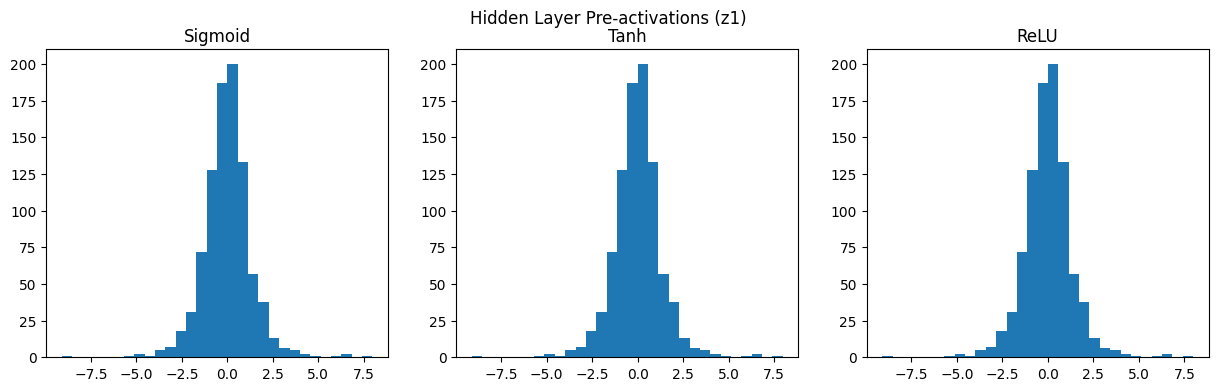

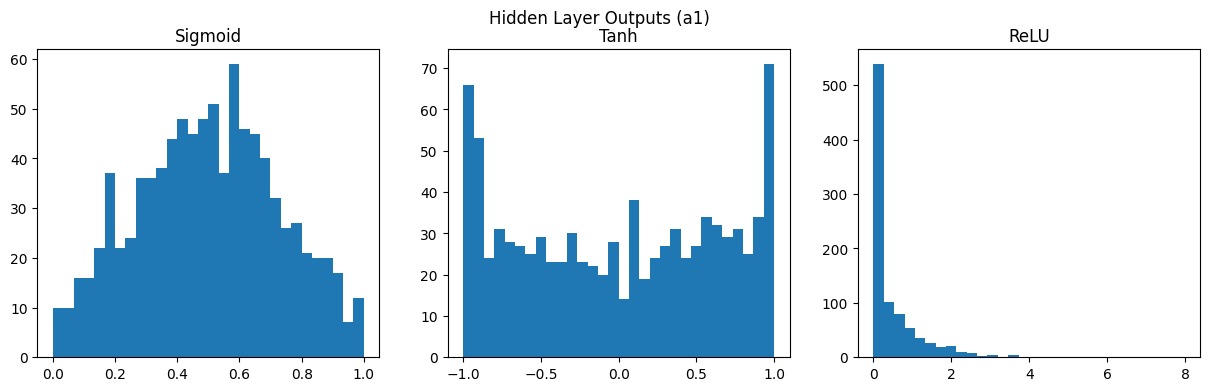

In [5]:
activations = {'Sigmoid': nn.Sigmoid(), 'Tanh': nn.Tanh(), 'ReLU': nn.ReLU()}
results = {}
for name, act in activations.items():
    with torch.no_grad():
        z1 = model_torch.fc1(X_test_tensor)
        a1 = act(z1)
        results[name] = {'z1': z1.numpy(), 'a1': a1.numpy()}

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 4))
fig1.suptitle('Hidden Layer Pre-activations (z1)')
for i, (name, res) in enumerate(results.items()):
    axes1[i].hist(res['z1'].flatten(), bins=30)
    axes1[i].set_title(name)
plt.show()

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle('Hidden Layer Outputs (a1)')
for i, (name, res) in enumerate(results.items()):
    axes2[i].hist(res['a1'].flatten(), bins=30)
    axes2[i].set_title(name)
plt.show()

**4.** 
- For Sigmoid, approximately 7.9% of values fall in saturated regions (<0.1 or >0.9). For Tanh, approximately 20.2% are saturated (<-0.9 or >0.9).
- For ReLU, roughly 49.6% of units are inactive (output exactly 0).
- ReLU is often a better default because it avoids saturation for positive values, mitigating the vanishing gradient problem and promoting sparse activations.